# Task 3 — House Price Category Prediction (Low / High)
Predict whether a house price is **Low** or **High** based on:
- `sqft_living` — area of the house
- `bedrooms` — number of rooms

Label is created by splitting on the **median price**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 1. Load Dataset

In [2]:
df = pd.read_csv('house_prices.csv') 
print('Shape:', df.shape)
df[['sqft_living', 'bedrooms', 'price']].describe()

Shape: (21613, 21)


,sqft_living,bedrooms,price
count,21613.000000,21613.000000,2.161300e+04
mean,2079.899736,3.370842,5.400881e+05
std,918.440897,0.930062,3.671272e+05
min,290.000000,0.000000,7.500000e+04
25%,1427.000000,3.000000,3.219500e+05
50%,1910.000000,3.000000,4.500000e+05
75%,2550.000000,4.000000,6.450000e+05
max,13540.000000,33.000000,7.700000e+06


## 2. Create Binary Label (Median Split)

Median Price : $450,000
Low  (0)     : 10692 samples
High (1)     : 10921 samples


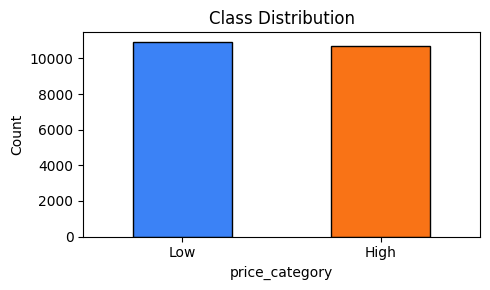

In [3]:
median_price = df['price'].median()
df['price_category'] = (df['price'] >= median_price).astype(int)

print(f'Median Price : ${median_price:,.0f}')
print(f'Low  (0)     : {(df["price_category"]==0).sum()} samples')
print(f'High (1)     : {(df["price_category"]==1).sum()} samples')

df['price_category'].value_counts().plot(kind='bar', color=['#3b82f6','#f97316'],
                                          edgecolor='black', figsize=(5,3))
plt.title('Class Distribution')
plt.xticks([0,1], ['Low','High'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Prepare Features & Split

In [4]:
X = df[['sqft_living', 'bedrooms']].values
y = df['price_category'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

Train: 17290  |  Test: 4323


## 4. Build Neural Network

In [5]:
model = keras.Sequential([
    layers.Input(shape=(2,)),           # sqft_living, bedrooms
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1,  activation='sigmoid'),
], name='house_price_classifier')

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "house_price_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6909 - loss: 0.6211 - val_accuracy: 0.7102 - val_loss: 0.5606
Epoch 2/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7244 - loss: 0.5391 - val_accuracy: 0.7091 - val_loss: 0.5571
Epoch 3/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7256 - loss: 0.5343 - val_accuracy: 0.7114 - val_loss: 0.5470
Epoch 4/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7268 - loss: 0.5331 - val_accuracy: 0.7114 - val_loss: 0.5467
Epoch 5/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7262 - loss: 0.5324 - val_accuracy: 0.7154 - val_loss: 0.5475
Epoch 6/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7263 - loss: 0.5318 - val_accuracy: 0.7097 - val_loss: 0.5491
Epoch 7/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7264 - loss: 0.5325 - val_accuracy: 0.7131 - val_loss: 0.5452
Epoch 8/50
487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7272 - loss: 0.5316 - val_accuracy: 0.

## 6. Evaluate

In [7]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print(f'Test Accuracy : {acc*100:.2f}%')
print(f'Test Loss     : {loss:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Low','High']))

Test Accuracy : 72.50%
Test Loss     : 0.5289

              precision    recall  f1-score   support

         Low       0.70      0.77      0.74      2139
        High       0.75      0.68      0.71      2184

    accuracy                           0.72      4323
   macro avg       0.73      0.73      0.72      4323
weighted avg       0.73      0.72      0.72      4323



## 7. Plots — Training Curve & Confusion Matrix

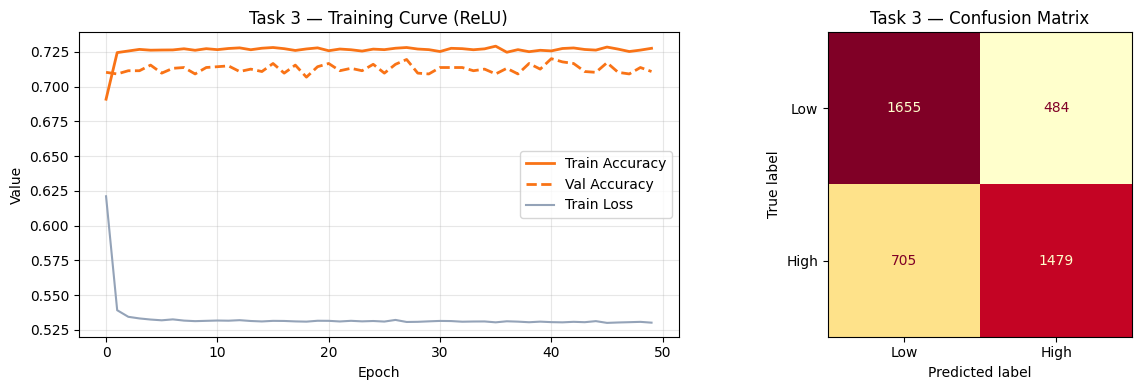

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Training curve
ax = axes[0]
ax.plot(history.history['accuracy'],     label='Train Accuracy', color='#f97316', lw=2)
ax.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#f97316', lw=2, ls='--')
ax.plot(history.history['loss'],         label='Train Loss',     color='#94a3b8', lw=1.5)
ax.set_title('Task 3 — Training Curve (ReLU)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Value')
ax.legend(); ax.grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low','High'])
disp.plot(ax=axes[1], colorbar=False, cmap='YlOrRd')
axes[1].set_title('Task 3 — Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

## 8. Sample Predictions

In [9]:
X_test_orig = scaler.inverse_transform(X_test)
results_df = pd.DataFrame({
    'sqft_living': X_test_orig[:, 0].astype(int),
    'bedrooms':    X_test_orig[:, 1].astype(int),
    'Actual':      ['High' if v else 'Low' for v in y_test],
    'Predicted':   ['High' if v else 'Low' for v in y_pred],
    'Probability': y_pred_prob.round(3),
    'Correct':     ['✓' if a==p else '✗' for a,p in zip(y_test, y_pred)],
})
results_df.head(12)

,sqft_living,bedrooms,Actual,Predicted,Probability,Correct
0,1610,3,High,Low,0.344,✗
1,880,2,Low,Low,0.147,✓
2,1070,3,Low,Low,0.148,✓
3,2800,5,High,High,0.735,✓
4,2490,4,High,High,0.683,✓
5,2690,4,Low,High,0.764,✗
6,3370,3,High,High,0.950,✓
7,1360,3,Low,Low,0.239,✓
8,1760,3,Low,Low,0.416,✓
9,4340,3,High,High,0.989,✓
